In [41]:
import orflib as orf
import numpy as np
import os
import matplotlib.pyplot as plt
plt.style.use('ggplot')

print("orflib version: {0}".format(orf.version()))
print("pid: {0}".format(os.getpid()))

orflib version: 0.10.0-debug
pid: 14532


Question 1 is in an attached PDF.
Question 2 code is implemented.

## Q3.1

In [42]:
assetrets = [0.09, 0.085, 0.08, 0.06, 0.05]
assetvols = [0.20, 0.20, 0.18, 0.16, 0.15]
correlmat = np.array([
    [1, 0, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 0, 1, 0],
    [0, 0, 0, 0, 1]])

rfreerate = 0.04

mvpwts = orf.mvpWghts(assetrets, assetvols, correlmat)
meanvarpwts = orf.meanVarWghts(assetrets, assetvols, correlmat, 0)

## Q 3.2

In [43]:
difference = mvpwts - meanvarpwts
print(difference.round(12))

[ 0.  0. -0.  0. -0.]


We see that both coeffecients are the same as returned by these functions.

## Q 3.3/3.4

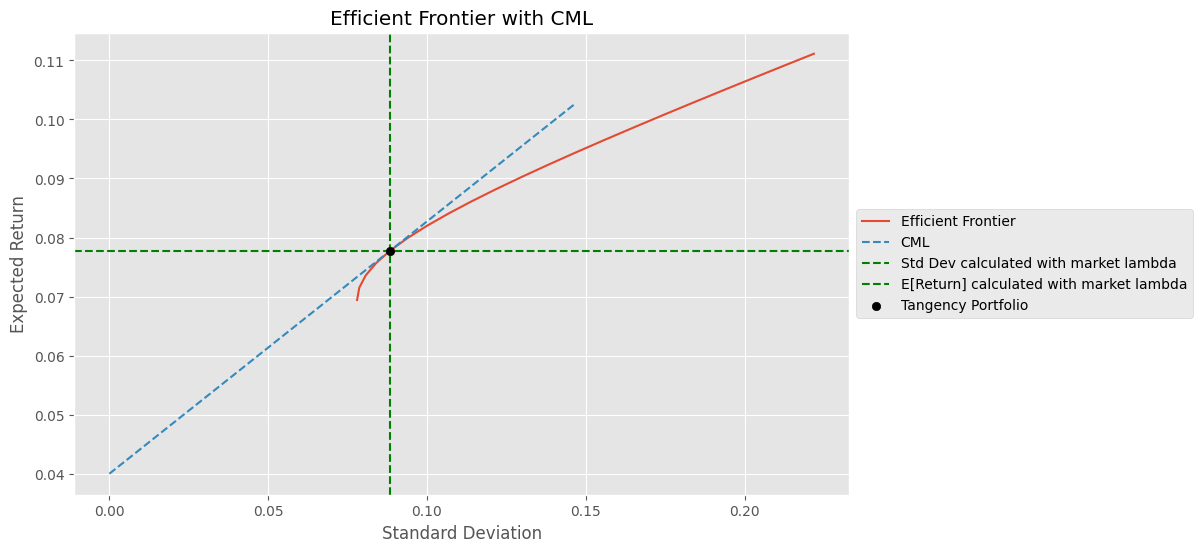

In [44]:
mktrisk = orf.mktRisk(assetrets, assetvols, correlmat, rfreerate)
meanvarfront = orf.meanVarFront(assetrets, assetvols, correlmat, mktrisk["Lambda"]*5, 20)
marketpwts = orf.meanVarWghts(assetrets, assetvols, correlmat, mktrisk["Lambda"])
mkt_ret = orf.ptRisk(marketpwts,assetrets, assetvols, correlmat)

plt.figure(figsize=(10, 6))  

plt.plot(meanvarfront["StdDev"], meanvarfront["Mean"], label="Efficient Frontier")

plt.ylabel("Expected Return")
plt.xlabel("Standard Deviation")
plt.title("Efficient Frontier with CML")


# CML: line from (0, rf) through tangency portfolio
x_cml = np.linspace(0, meanvarfront["StdDev"][12], 100)
y_cml = rfreerate + (mktrisk["Mean"] - rfreerate) / mktrisk["StdDev"] * x_cml

plt.plot(x_cml, y_cml, linestyle='--', label="CML")

plt.axvline(x=mkt_ret["StdDev"], color='green', linestyle='--', label='Std Dev calculated with market lambda')
plt.axhline(y=mkt_ret["Mean"], color='green', linestyle='--', label='E[Return] calculated with market lambda')
plt.scatter([mktrisk["StdDev"]], [mktrisk["Mean"]], color='black', zorder=5, label="Tangency Portfolio")

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True)
plt.show()

Here we see the efficient frontier starting from the MVP along with the CML.
We see that the market portfolio as marked is at thetangency point of the CML and the efficient frontier.
We also double check the lambda by calculating the expected return and standard deviation for the calculated market lambda and confirming that this is the same point.